In [18]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder

import seaborn as sns
from utilClassification import check_dist, pca, optimize, model_performance, data_preparation

In [20]:
plt.rcParams.update({'font.size': 10,
                     'axes.titlesize': 'medium',
                     'axes.grid': False})

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

## Load Data

In [21]:
# load landuse, label, trail/nontrail information
landuse_information = pd.read_csv('data/landuse_information.csv')
month_to_year_group = pd.read_csv('data/month_to_year_group.csv', dtype = {'site_id': str})
locations = pd.read_csv('data/locations_combine_site.csv', dtype = {'site_id':str})

In [22]:
# Load climate data
explanatory_var_p1 = pd.read_excel('data/all_Locations_p1_11_26_2024.xlsx')
explanatory_var_p1.loc[explanatory_var_p1.id == '100039878', 'id'] = '100039878100005462'
explanatory_var_p1.loc[explanatory_var_p1.id == '300025945', 'id'] = '300025945100021712'

In [23]:
# prepare data for training: 
# get trail/nontrail info, 
# calculate percentage of different kinds of businesses within certain buffer, 
# get climate info,
# year / year group indicators
data_encoded = data_preparation(month_to_year_group, landuse_information, climate_df = explanatory_var_p1, trail_df = locations)

In [24]:
data_encoded.shape

(290, 134)

In [25]:
# entertainment, heavy/light industry, office, others, retail usually has a higher raw number
# colleges, recreation, schools, travel&accomodation has a lower raw number

# offices, others, retail usually takes up a higher percentage, meaning these areas are usually urban (?)
# Entertainment takes up a relative medium percentage (~10%)
# colleges, heavy/light industry, recreation, schools, travel & accomodation takes up a relative low percentage
data_encoded.describe()

,label,trail,colleges_2,entertainment_2,heavy industry_2,light industry_2,offices_2,others_2,recreation_2,retail_2,...,year_2013,year_2014,year_2015,year_2016,year_2017,year_2018,year_2019,year_2020,year_2021,year_2022
count,290.000000,290.000000,290.000000,290.000000,290.000000,290.000000,290.000000,290.000000,290.000000,290.000000,...,290.000000,290.000000,290.000000,290.000000,290.000000,290.000000,290.000000,290.000000,290.000000,290.000000
mean,1.000000,0.762069,0.051724,3.141379,1.275862,2.600000,7.331034,6.289655,0.134483,6.362069,...,0.051724,0.055172,0.068966,0.124138,0.117241,0.124138,0.148276,0.110345,0.075862,0.124138
std,0.616946,0.426553,0.301232,11.746339,9.824750,26.030831,22.537183,26.349374,0.361443,46.794810,...,0.221852,0.228711,0.253834,0.330309,0.322264,0.330309,0.355988,0.313861,0.265235,0.330309
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,5.000000,3.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,3.000000,1.000000,3.000000,82.000000,119.000000,323.000000,290.000000,285.000000,2.000000,573.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## EDA

In [26]:
data_encoded.label.value_counts()

label
1    207
0     46
2     28
3      9
Name: count, dtype: int64

In [27]:
data_encoded.groupby('label')['covid_covid'].value_counts(normalize = True)

label  covid_covid
0      0.0            0.891304
       1.0            0.108696
1      0.0            0.816425
       1.0            0.183575
2      0.0            0.607143
       1.0            0.392857
3      0.0            1.000000
Name: proportion, dtype: float64

In [28]:
data_encoded.columns.to_list()

['label',
 'trail',
 'colleges_2',
 'entertainment_2',
 'heavy industry_2',
 'light industry_2',
 'offices_2',
 'others_2',
 'recreation_2',
 'retail_2',
 'schools_2',
 'travel & accommodation_2',
 'total_2',
 'colleges_4',
 'entertainment_4',
 'heavy industry_4',
 'light industry_4',
 'offices_4',
 'others_4',
 'recreation_4',
 'retail_4',
 'schools_4',
 'travel & accommodation_4',
 'total_4',
 'colleges_6',
 'entertainment_6',
 'heavy industry_6',
 'light industry_6',
 'offices_6',
 'others_6',
 'recreation_6',
 'retail_6',
 'schools_6',
 'travel & accommodation_6',
 'total_6',
 'colleges_8',
 'entertainment_8',
 'heavy industry_8',
 'light industry_8',
 'offices_8',
 'others_8',
 'recreation_8',
 'retail_8',
 'schools_8',
 'travel & accommodation_8',
 'total_8',
 'colleges_10',
 'entertainment_10',
 'heavy industry_10',
 'light industry_10',
 'offices_10',
 'others_10',
 'recreation_10',
 'retail_10',
 'schools_10',
 'travel & accommodation_10',
 'total_10',
 'per_colleges_2',
 'per

In [29]:
data_encoded.groupby('label')['snow'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,46.0,0.652174,1.753947,0.0,0.0,0.0,0.0,9.0
1,207.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
2,28.0,0.750000,2.413312,0.0,0.0,0.0,0.0,10.0
3,9.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


In [30]:
data_encoded.groupby('label')['snow'].value_counts()

label  snow
0      0.0      39
       3.0       4
       4.0       1
       5.0       1
       9.0       1
1      0.0     207
2      0.0      25
       3.0       1
       8.0       1
       10.0      1
3      0.0       9
Name: count, dtype: int64

### 1) Boxplot

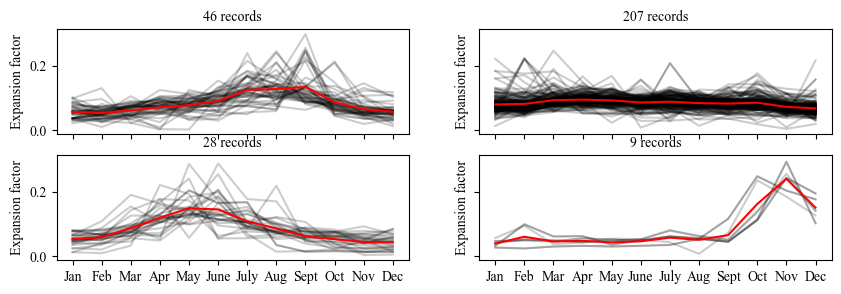

In [31]:
from IPython.display import Image
Image("mty.png")

In [17]:
display(data_encoded.loc[:,['precip_5in', 'precip_1in', 'label']].groupby(['label']).describe())
display(data_encoded.loc[:,['temp90', 'snow', 'label']].groupby(['label']).describe())

precip_5in                                                  precip_1in  \
           count       mean       std  min  25%   50%   75%   max      count   
label                                                                          
0           46.0  10.826087  6.161906  2.0  6.0  10.0  13.5  34.0       46.0   
1          207.0   9.304348  5.940574  2.0  4.0   8.0  12.0  34.0      207.0   
2           28.0   9.500000  7.239296  2.0  4.0   8.5  12.5  36.0       28.0   
3            9.0   6.444444  3.282953  3.0  3.0   9.0   9.0  10.0        9.0   

                                                     
           mean       std  min  25%  50%  75%   max  
label                                                
0      3.565217  2.535544  0.0  2.0  3.0  5.0  13.0  
1      2.777778  1.905253  0.0  2.0  3.0  4.0  12.0  
2      3.607143  4.219349  0.0  2.0  2.0  4.0  21.0  
3      1.555556  1.236033  0.0  1.0  2.0  2.0   4.0

temp90                                                       snow  \
       count       mean        std  min   25%  50%    75%    max  count   
label                                                                     
0       46.0  18.934783  30.665509  0.0  3.25  9.0  12.25  131.0   46.0   
1      207.0  28.497585  36.677005  0.0  3.00  9.0  49.00  127.0  207.0   
2       28.0  17.642857  32.497538  0.0  2.50  4.5  11.50  115.0   28.0   
3        9.0   4.444444   2.603417  0.0  4.00  6.0   6.00    6.0    9.0   

                                                     
           mean       std  min  25%  50%  75%   max  
label                                                
0      0.652174  1.753947  0.0  0.0  0.0  0.0   9.0  
1      0.000000  0.000000  0.0  0.0  0.0  0.0   0.0  
2      0.750000  2.413312  0.0  0.0  0.0  0.0  10.0  
3      0.000000  0.000000  0.0  0.0  0.0  0.0   0.0

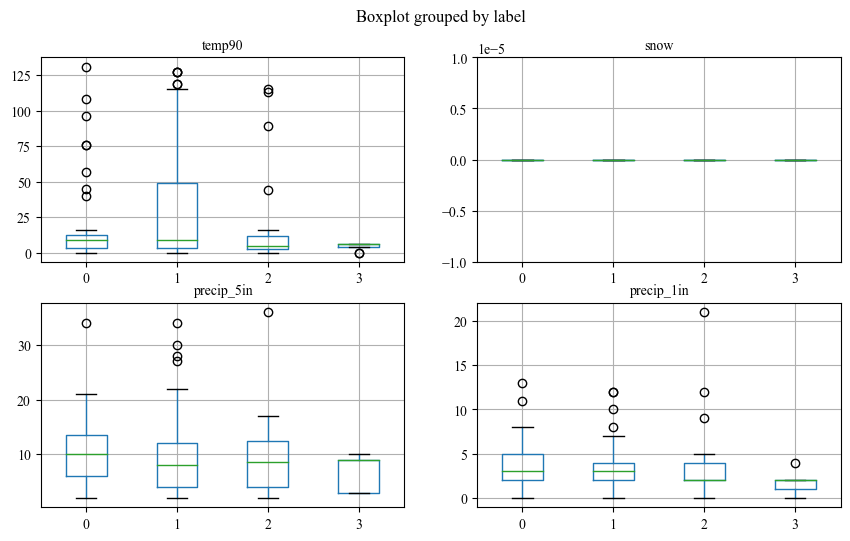

In [48]:
# High Temperature: Number of days temperature > 90 F (Median >= 7 days)

# Cluster 0: (hot, relatively more rain) more days (median = 9) with temperature greater than 90 F, 
#                          number of days with precipitation > 0.5 inch (median = 10 days) 
#                          number of days with precipitation > 1 inch (median = 3 days)
# Cluster 1: (relative hot, moderate amount of rain) 
#                          more days (median = 9) with temperature greater than 90 F (large variation across locations), 
#                          number of days with precipitation > 0.5 inch (median = 8 days) 
#                          number of days with precipitation > 1 inch (median = 3 days)
# Cluster 2: (relative cooler, moderate amount of rain): less days (median = 4.5) with temperature > 90 F, 
#                                                        number of days with precipitation > 0.5 inch (median = 8.5 days) 
#                                                        number of days with precipitation > 1 inch (median = 2 days)
# Cluster 3: (relative cooler, moderate amount of rain) less days (median = 6) with temperature > 90 F, 
#                              number of days with precipitation > 0.5 inch (median = 9 days), 
#                              number of days with precipitation > 1 inch (median = 2 days)
fig, axes = plt.subplots(2, 2, figsize = (10, 6))
data_encoded.boxplot(column = 'temp90', by = 'label', ax = axes[0,0])
data_encoded.boxplot(column = 'snow', by = 'label', ax = axes[0,1])
axes[0, 1].set_ylim([-0.00001, 0.00001])
data_encoded.boxplot(column = 'precip_5in', by = 'label', ax = axes[1,0])
data_encoded.boxplot(column = 'precip_1in', by = 'label', ax = axes[1,1])
for ax in axes.flat:
    ax.set_xlabel('')

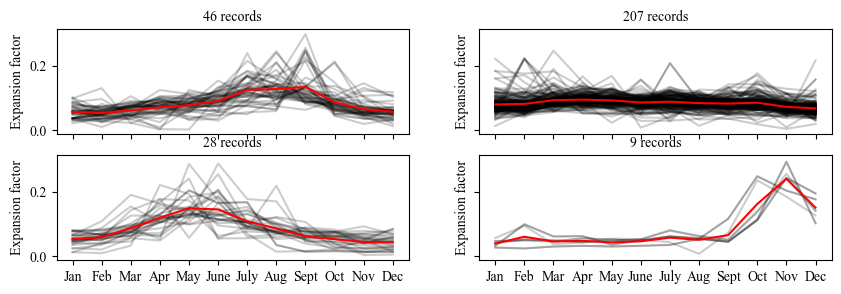

In [158]:
from IPython.display import Image
Image("mty.png")

- colleges: 
    - Junior Colleges, Colleges, Universities, and Professional Schools, Technical and Trade Schools
- schools: 
    - elementary and secondary schools
- entertainment: 
    - Food and beverage retails, 
    - performing arts, spectator sports, 
    - amusement parks, gambling
- recreation: 
    - Museums, Historical Sites, and Similar Institutions
- travel & accommodation: 
    - Gasoline Stations and Fuel Dealers, 
    - Transit and Ground Passenger Transportation, Accommodation
- retail: 
    - All kinds of retailers
- heavy industry: 
    - Mining, Quarrying, and Oil and Gas Extraction, 
    - Utilities, 
    - Manufacturing
- light industry: 
    - Wholesale Trade, 
    - Transportation and Warehousing
- offices: 
    - construction, Information, 
    - Finance and Insurance, 
    - Real Estate and Rental and Leasing, 
    - Professional, Scientific, and Technical Services, Management of Companies and Enterprises, 
    - Administrative and Support and Waste Management and Remediation Services, 
    - Business Schools and Computer and Management Training, 
    - Educational Support Services
- others: 
    - Agriculture, Forestry, Fishing and Hunting


In [71]:
data_encoded.loc[:,['total_6', 'total_8', 'label']].groupby(['label']).describe()

total_6                                                             \
        count        mean         std   min    25%    50%    75%     max   
label                                                                      
0        46.0  141.652174  170.229808   0.0  40.25  109.0  192.5  1057.0   
1       207.0  220.449275  684.019336   0.0  28.00   91.0  215.0  6573.0   
2        28.0   84.428571   83.684783   1.0  16.50   57.5  144.0   345.0   
3         9.0   79.444444   38.913722  29.0  56.00   85.0   88.0   168.0   

      total_8                                                                 
        count        mean          std    min     25%    50%     75%     max  
label                                                                         
0        46.0  254.760870   244.264354    3.0  141.75  237.5  281.75  1397.0  
1       207.0  394.884058  1029.219558    0.0  100.00  219.0  364.00  9305.0  
2        28.0  224.464286   194.327803    5.0   86.50  158.0  320.00   720.0  
3         9.0  159.111111    28.902614  136.0  140.00  145.0  182.00   219.0

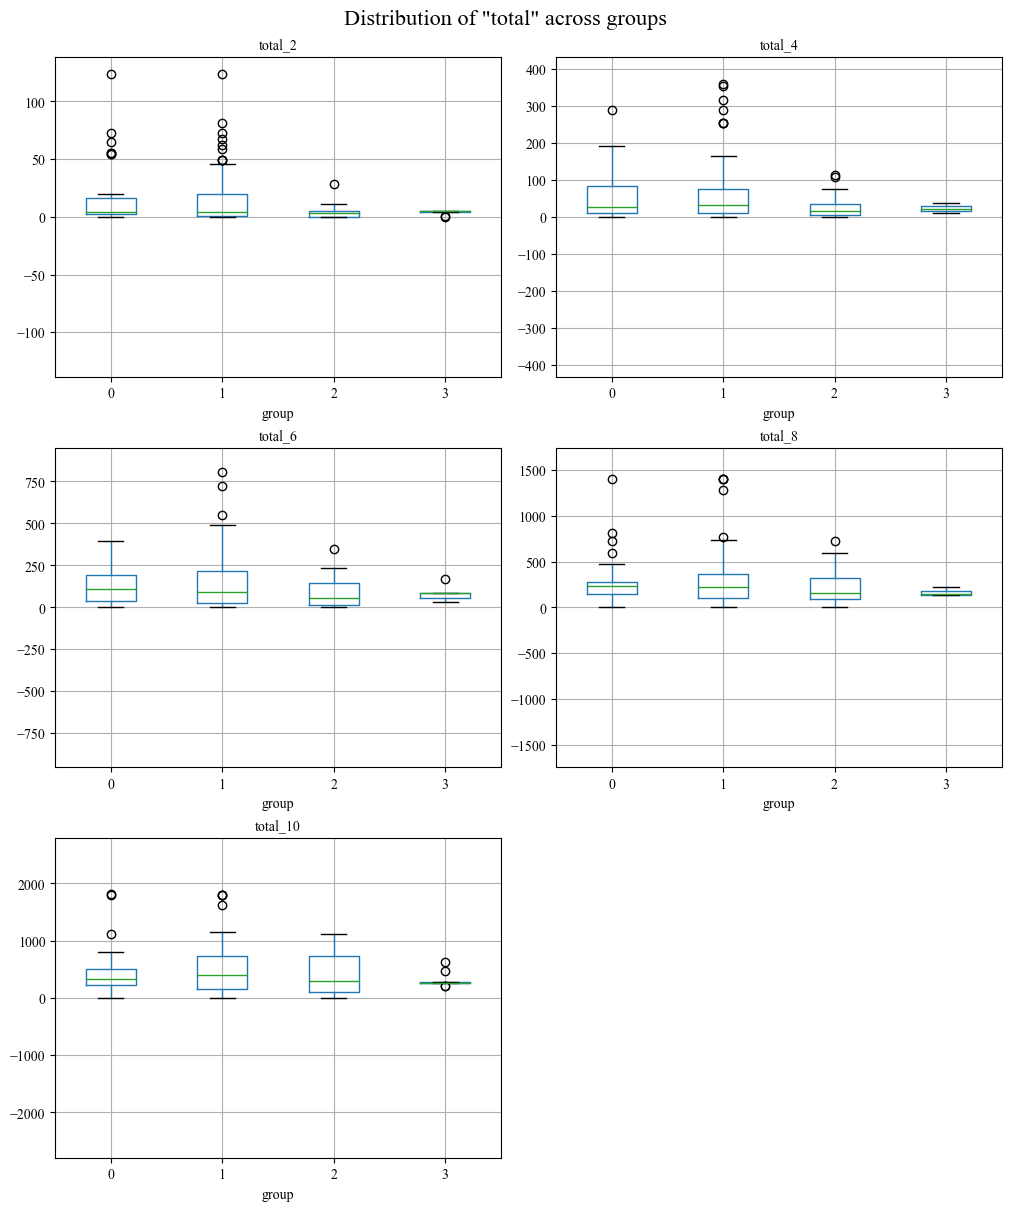

In [52]:
# variables: colleges, school, 
#            entertainment, recreation, travel & accomodation, retail
#            heavy industry, light industry, 
#            offices, others, total


# Number of total categories within 600 meters: HIGH DENSITY (Median >= 90)

# Cluster 0: (dense retail area) higher number of categories within 600 meters (median = 109, mean = 142), 
#                                higher percentage of retails within 400/600 meters

# Cluster 1: (relatively dense area with heavy industry and retail businesses) 
#             schools within 600 meters, colleges within 800 meters, 
#             higher percentage of heavy industry within 400 meters, 
#             higher percentage of retails within 400/600 meters, 
#             higher number of categoies within 600 meters (median = 91, mean = 220)

# Cluster 2: (mixed of recreation of offices) higher percentage of recreation within 400 meters, 
#             higher percentage of offices within 600/800 meters, 
#             lower percentage of retails within 400/600 meters
#             relative lower number of categories within 600 meters (median = 57.5, mean = 84)

# Cluster 3: (entertainment and travel area) higher percentage of entertainment facilities within 400/600/800 meters, 
#            high percentage of travel & accommodation / light industry within 600/800 meters
#            relative lower number of categories within 600 meters (median = 85, mean = 79)

check_dist(data_encoded, 'total')

### 2) Pearson correlation between variables

In [54]:
vars_ = ['colleges', 'entertainment', 'heavy industry', 'light industry', 
       'offices', 'others', 'recreation', 'retail', 'schools', 'travel & accommodation', 'total', 
       'per_colleges', 'per_entertainment', 'per_heavy industry', 'per_light industry',
       'per_offices', 'per_others', 'per_recreation', 'per_retail', 'per_schools', 'per_travel & accommodation']

<AxesSubplot:>

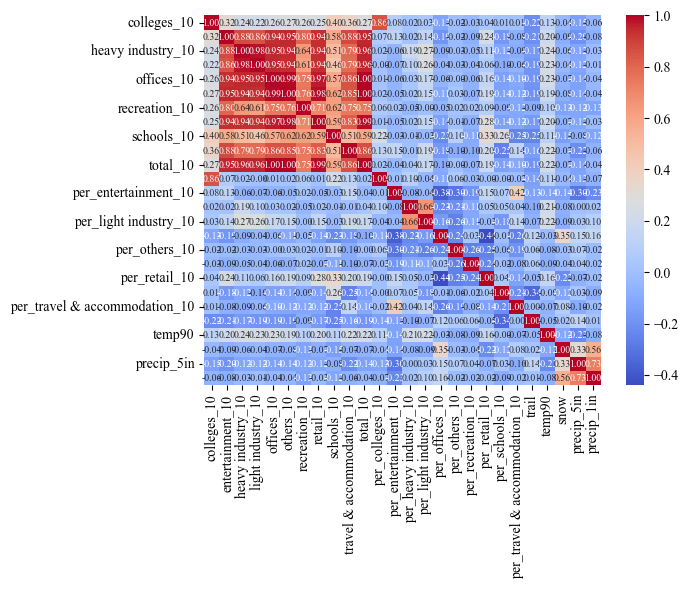

In [55]:
# number of days with precipation > 1 inch has a relative stronger correlation with snow (0.56), a high correlation with number of days with precipation greater than 0.5 inch
# raw number of colleges (0.22~0.4) /schools (0.46~0.62) has a low correlation with the raw number of other businesses
# raw number of recreation (0.61 ~ 0.8), travel & accommodation (0.51~0.88) has a medium to high correlation with other raw numbers
# percentage of light industry has a high correlation with percentage of heavy industry (0.66)
# percentage of colleges has a high correlation with number of colleges (0.86)
suffix = '_10'
varnames = [var + suffix for var in vars_] + ['trail', 'temp90','snow','precip_5in','precip_1in']
plt.plot(figsize = (30, 30))
sns.heatmap(data_encoded[varnames].corr(), cmap = 'coolwarm', annot = True, fmt = '.2f', annot_kws = {'fontsize': 7})

In [86]:
data_encoded.columns.to_list()

['label',
 'trail',
 'colleges_2',
 'entertainment_2',
 'heavy industry_2',
 'light industry_2',
 'offices_2',
 'others_2',
 'recreation_2',
 'retail_2',
 'schools_2',
 'travel & accommodation_2',
 'total_2',
 'colleges_4',
 'entertainment_4',
 'heavy industry_4',
 'light industry_4',
 'offices_4',
 'others_4',
 'recreation_4',
 'retail_4',
 'schools_4',
 'travel & accommodation_4',
 'total_4',
 'colleges_6',
 'entertainment_6',
 'heavy industry_6',
 'light industry_6',
 'offices_6',
 'others_6',
 'recreation_6',
 'retail_6',
 'schools_6',
 'travel & accommodation_6',
 'total_6',
 'colleges_8',
 'entertainment_8',
 'heavy industry_8',
 'light industry_8',
 'offices_8',
 'others_8',
 'recreation_8',
 'retail_8',
 'schools_8',
 'travel & accommodation_8',
 'total_8',
 'colleges_10',
 'entertainment_10',
 'heavy industry_10',
 'light industry_10',
 'offices_10',
 'others_10',
 'recreation_10',
 'retail_10',
 'schools_10',
 'travel & accommodation_10',
 'total_10',
 'per_colleges_2',
 'per

### 3) ANOVA analysis

In [98]:
from sklearn.feature_selection import f_classif

f_statistic, p_values = f_classif(data_encoded.loc[:, 'trail':], data_encoded['label'])
anova = pd.DataFrame({'variable': data_encoded.columns[1:], 'p_values': p_values}).sort_values(by = 'p_values')

In [115]:
# Variables with high correlation with label
# snow, precip_1in, temp90, precip_5in

# per_offices_6, per_travel & accommodation_8, per_others_6, per_entertainment_10, schools_10, 
# per_recreation_2, per_retail_4, per_light industry_4, per_heavy industry_2, per_colleges_2, total_10

# covid_covid, year_group_2021, year_group_171819, year_group_1516, covid_pre-covid, year_group_1314, covid_post-covid, year_group_22
anova[anova.p_values <= 0.6][-20:]

,variable,p_values
63,per_retail_2,0.477353
49,offices_10,0.508536
111,covid_post-covid,0.509919
117,year_group_22,0.509919
127,year_2022,0.509919
39,others_8,0.512562
45,colleges_10,0.523003
30,retail_6,0.534013
6,others_2,0.538371
34,colleges_8,0.539530


### 4) PCA

In [116]:
from sklearn.decomposition import PCA

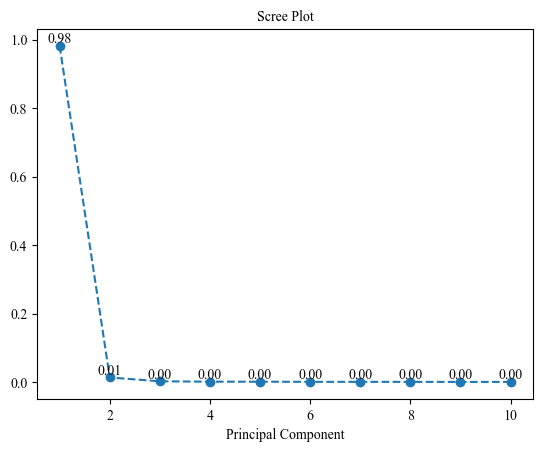

In [120]:
pca = pca(data_encoded)

In [134]:
# total_10, offices_10, others_8, retail_10, light industry_10, entertainment_10
# heavy industry_10, travel & accommodation_10, recreation_10, schools_10, colleges_10
# temp90
# covid_post-covid, year_group_22, year_2022, year_group_1314
pd.DataFrame({'varname': data_encoded.columns[1:], '1st_pca_coefficient': pca.components_[0, :]}).sort_values(by = '1st_pca_coefficient', ascending = False).head(90)[-10:]

,varname,1st_pca_coefficient
88,per_heavy industry_8,6.122421e-07
98,per_heavy industry_10,5.551779e-07
120,year_2015,4.695722e-07
91,per_others_8,1.814751e-07
86,per_colleges_8,1.354730e-07
76,per_colleges_6,1.062409e-07
66,per_colleges_4,1.053770e-07
96,per_colleges_10,8.300974e-08
56,per_colleges_2,-7.410433e-11
101,per_others_10,-1.187627e-07


### Model Estimation

In [9]:
from hyperopt import hp

In [10]:
# Set cross-validation parameters
num_folds = 10
kf = KFold(n_splits = num_folds)
random_state = 40

In [11]:
data_encoded.columns

Index(['label', 'trail', 'colleges_2', 'entertainment_2', 'heavy industry_2',
       'light industry_2', 'offices_2', 'others_2', 'recreation_2', 'retail_2',
       ...
       'year_2013', 'year_2014', 'year_2015', 'year_2016', 'year_2017',
       'year_2018', 'year_2019', 'year_2020', 'year_2021', 'year_2022'],
      dtype='object', length=134)

In [12]:
var = ['total_10', 'total_8',
       'colleges_10', 'per_colleges_10',                               'per_colleges_2',
       'entertainment_10', 'per_entertainment_10', 
       'per_heavy industry_8', 'per_heavy industry_10',                'per_heavy industry_2',
       'per_light industry_10',                                        'per_light industry_4',
       'per_offices_8', 'per_offices_10',                              'per_offices_6',
       'per_others_8', 'per_others_10',                                'per_others_6',
       'recreation_10', 'per_recreation_10',                           'per_recreation_2',
       'per_retail_10',                                                'per_retail_4', 
       'per_schools_10', 'schools_10',
       'travel & accommodation_10', 'per_travel & accommodation_10',   'per_travel & accommodation_8',
       'trail', 'temp90', 'snow', 'precip_5in', 'precip_1in',
       'year_group_2021',"year_group_171819", "year_group_1516", "year_group_1314",  "year_group_2223",
       "covid_pre-covid", 'covid_covid', "covid_post-covid"]

In [11]:
# Prepare label, features dataset
y, X = data_encoded['label'], data_encoded.drop('label', axis = 1)
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 40)

In [18]:
# from imblearn.over_sampling import SMOTE
# Resample the dataset to make the number of instances in each class equal
# oversample = SMOTE()
# X_train, y_train = oversample.fit_resample(X_train, y_train)

### Random Forest

In [16]:
from sklearn.ensemble import RandomForestClassifier

In [16]:
import warnings
warnings.filterwarnings('ignore', category = UserWarning, module = 'sklearn.metrics._classification')

In [21]:
# perform cross validation to find the best set of hyper-parameters
rfc = RandomForestClassifier

params = {
            'n_estimators': [i for i in range(50, 2001, 50)],
            'max_depth': [i for i in range(2, 151)],
            'min_samples_leaf': [i for i in range(1, 6)],
            'min_samples_split': [i for i in range(2, 10)],
            'class_weight': ['balanced'],
            'max_features': ['sqrt', 'log2']
         }

space = {'n_estimators': hp.choice('n_estimators', params['n_estimators']),
          'max_depth': hp.choice('max_depth', params['max_depth']),
          'min_samples_leaf': hp.choice('min_samples_leaf', params['min_samples_leaf']),      # minimum amount of samples in a leaf, prevent overfitting
          'min_samples_split': hp.choice('min_samples_split', params['min_samples_split']),
          'class_weight': hp.choice('class_weight', params['class_weight']),
          'max_features': hp.choice('max_features', params['max_features'])
         }

best = optimize(rfc, space, n_iter = 100, random_state = random_state, cv = kf, X = X_train, Y = y_train)

100%|█████████████████████████████████████████████| 100/100 [21:59<00:00, 13.20s/trial, best loss: -0.4747691709591864]


In [22]:
print(best)

{'class_weight': 0, 'max_depth': 49, 'max_features': 0, 'min_samples_leaf': 0, 'min_samples_split': 2, 'n_estimators': 31}


In [23]:
best_params = {key: params[key][value] for key, value in best.items()}
rfc = RandomForestClassifier
ac_tr_rfc, ac_cv_rfc, ac_tt_rfc = model_performance(X_train = X_train, y_train = y_train, X_test = X_test, y_test = y_test, model = rfc, cv = kf, params = best_params, random_state = random_state)

The prediction accuracy of train set is 97.4%
The confusion matrix is:
[[ 37   0   1   0]
 [  3 160   2   0]
 [  0   0  21   0]
 [  0   0   0   8]]
-----------------------------------------
The prediction accuracy of 10 fold cross-validation is 47.5%
-----------------------------------------
The prediction accuracy of test set is 65.5%
The confusion matrix is:
[[ 2  4  1  1]
 [ 4 35  0  3]
 [ 1  5  0  1]
 [ 0  0  0  1]]


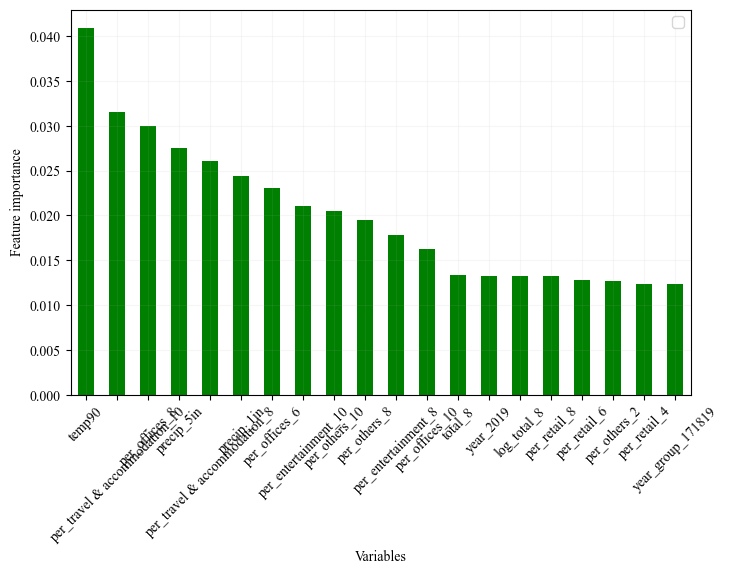

In [24]:
# check the feature importance of random forest
rfc = RandomForestClassifier(random_state = random_state, **best_params)
rfc.fit(X_train, y_train)
feature_importances = pd.DataFrame({'varname': X_train.columns, 'Importance': rfc.feature_importances_}).sort_values(by = 'Importance', ascending = False)
feature_importances.set_index('varname', inplace = True)

ax = feature_importances.head(20).plot(kind = 'bar', rot = 45, figsize = (8, 5), color = 'green')
ax.set_xlabel('Variables')
ax.set_ylabel('Feature importance')
ax.legend('')
plt.grid(alpha = .1)

### XGBoost

In [12]:
from xgboost import XGBClassifier, plot_importance

In [14]:
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes = np.unique(y_train), y=y_train)
sample_weight = np.array([class_weights[label] for label in y_train])

In [15]:
xgb = XGBClassifier

params = {
            'max_depth': [i for i in range(2, 151)],
            'n_estimators': [i for i in range(50, 2001, 50)],
            'gamma': [i for i in range(11)],
            'min_child_weight': [i for i in range(10)],
}

space = {'max_depth': hp.choice("max_depth", params['max_depth']),            
         'n_estimators': hp.choice('n_estimators', params['n_estimators']),
         'gamma': hp.choice('gamma', params['gamma']),                                       # mininum loss reduction required to make a split, similar to pruning
         'min_child_weight' : hp.choice('min_child_weight', params['min_child_weight']),     # minimum sum of weights of all observations required in a child, control overfitting
         'reg_alpha' : hp.uniform('reg_alpha', 0,1),                                         # L1 regularization on weights, high value -> conservative
         'reg_lambda' : hp.uniform('reg_lambda', 0,1),                                       # L2 regularization on weights, high value -> conservative
         'colsample_bytree' : hp.uniform('colsample_bytree', 0,1),                           # the fraction of columns to be subsampled         
        }

best = optimize(xgb, space, n_iter = 100, random_state = random_state, cv = kf, X = X_train, Y = y_train)

In [18]:
print(best)

{'colsample_bytree': 0.16403793814229886, 'gamma': 0, 'max_depth': 115, 'min_child_weight': 8, 'n_estimators': 1, 'reg_alpha': 0.2985104663791442, 'reg_lambda': 0.04171108352146058}


In [13]:
best = {'colsample_bytree': 0.16403793814229886, 'gamma': 0, 'max_depth': 115, 'min_child_weight': 8, 'n_estimators': 1, 'reg_alpha': 0.2985104663791442, 'reg_lambda': 0.04171108352146058}

In [16]:
best_params = {key: params[key][value] if key in ['max_depth', 'n_estimators', 'gamma', 'min_child_weight'] else value for key, value in best.items()}
xgb = XGBClassifier
ac_tr_xgb, ac_cv_xgb, ac_tt_xgb = model_performance(X_train = X_train, y_train = y_train, X_test = X_test, y_test = y_test, model = xgb, cv = kf, params = best_params, random_state = random_state)

The prediction accuracy of train set is 90.9%
The confusion matrix is:
[[ 30   7   1   0]
 [  0 165   0   0]
 [  2   7  12   0]
 [  1   3   0   4]]
-----------------------------------------


C:\Users\Qianhua\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1999: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


The prediction accuracy of 10 fold cross-validation is 51.7%
-----------------------------------------
The prediction accuracy of test set is 72.4%
The confusion matrix is:
[[ 2  5  1  0]
 [ 3 39  0  0]
 [ 2  5  0  0]
 [ 0  0  0  1]]


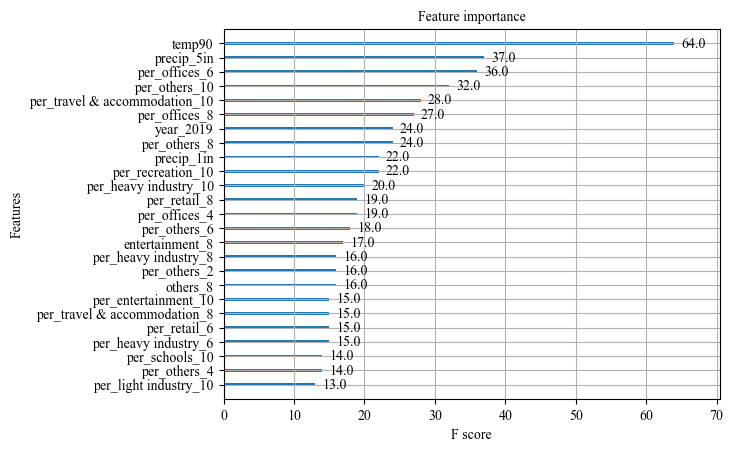

In [27]:
xgb = XGBClassifier(random_state = random_state, **best_params)
xgb.fit(X_train, y_train)
sorted_idx = np.argsort(xgb.feature_importances_)[::-1]
xgb.feature_importances_[sorted_idx]
plot_importance(xgb, max_num_features = 25)
plt.show()

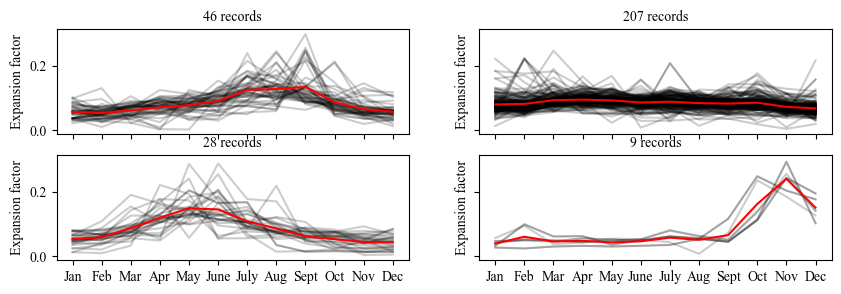

In [156]:
from IPython.display import Image
Image("mty.png")

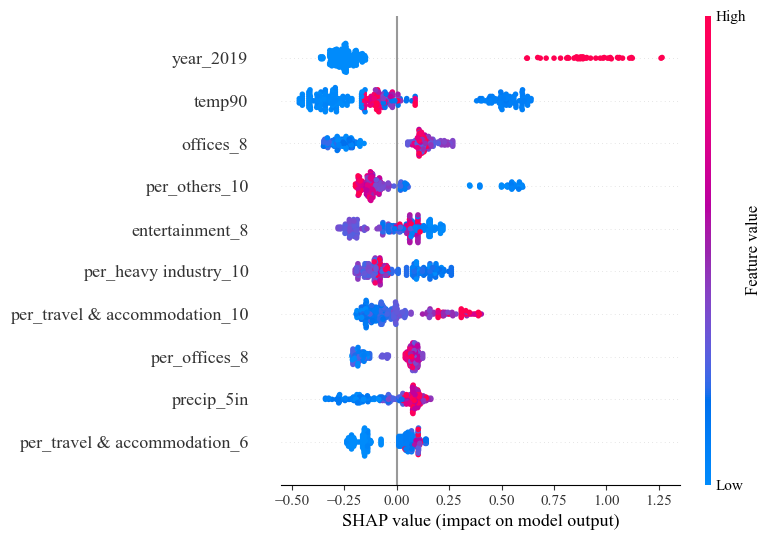

In [173]:
# Check SHAP value
# Cluster 0: records collected in 2019, locations with a high percentage of travel and accomodation but low percentage of others, schools, and recreation,
#            and with high number of days with percipation greater than 0.5 inch 
# Cluster 1: high number of days with precipation > 1 inch & temperature > 90F, high percentage of recreation, low percantage of entertianment
# Cluster 2: (CBD area?) low (?) number of days with temperature higher than 90F, high percentage of offices, data collected pre-covid
# Cluster 3: low precipation, high percentage of retails, but low percentage and raw number of offices, low number of total businesses
import shap
explainer = shap.TreeExplainer(xgb)
shap_values = explainer(X)
shap.summary_plot(shap_values[:,:,0], X, max_display=10)

### Multinomial Logit

In [38]:
import statsmodels.api as sm
from utilClassification import SMWrapperMNL

In [39]:
var = ['total_10', 
       'per_colleges_10', 
       'per_entertainment_8', 
                                                                       'per_heavy industry_2',
                                                                       'per_light industry_4',
       'per_offices_4',                                              
       'per_others_4',                                               
                                                                       'per_recreation_2',
                                                                       'per_retail_4', 
       'per_schools_10',
       'per_travel & accommodation_8',                               
       'trail', 
       'temp90', 
       # 'snow', 
       'precip_1in',
       # "year_group_1314","year_group_1516","year_group_171819",'year_group_2021',  
       'year_2013', 'year_2014','year_2015','year_2016','year_2017','year_2018','year_2019','year_2020', 'year_2021', 
#        "covid_pre-covid", 'covid_covid'
      ]

In [40]:
X_train[var].describe()

,total_10,per_colleges_10,per_entertainment_8,per_heavy industry_2,per_light industry_4,per_offices_4,per_others_4,per_recreation_2,per_retail_4,per_schools_10,...,precip_1in,year_2013,year_2014,year_2015,year_2016,year_2017,year_2018,year_2019,year_2020,year_2021
count,232.000000,232.000000,232.000000,232.000000,232.000000,232.000000,232.000000,232.000000,232.000000,232.000000,...,232.000000,232.000000,232.000000,232.000000,232.000000,232.000000,232.000000,232.000000,232.000000,232.000000
mean,575.331897,0.001452,0.101405,0.018089,0.025289,0.320933,0.288387,0.015297,0.131239,0.010045,...,2.974138,0.056034,0.060345,0.060345,0.125000,0.116379,0.133621,0.155172,0.099138,0.068966
std,1230.580698,0.004130,0.062965,0.045633,0.041299,0.174930,0.202422,0.068682,0.124539,0.010890,...,2.335353,0.230486,0.238639,0.238639,0.331434,0.321373,0.340980,0.362852,0.299493,0.253943
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,160.000000,0.000000,0.069005,0.000000,0.000000,0.222222,0.180481,0.000000,0.032653,0.002716,...,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,350.500000,0.000000,0.083333,0.000000,0.000000,0.333333,0.250000,0.000000,0.111111,0.007745,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,635.000000,0.002231,0.122745,0.000000,0.033333,0.425926,0.333333,0.000000,0.177778,0.013393,...,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,11410.000000,0.040000,0.400000,0.200000,0.285714,1.000000,1.000000,0.500000,0.687500,0.068966,...,21.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<AxesSubplot:>

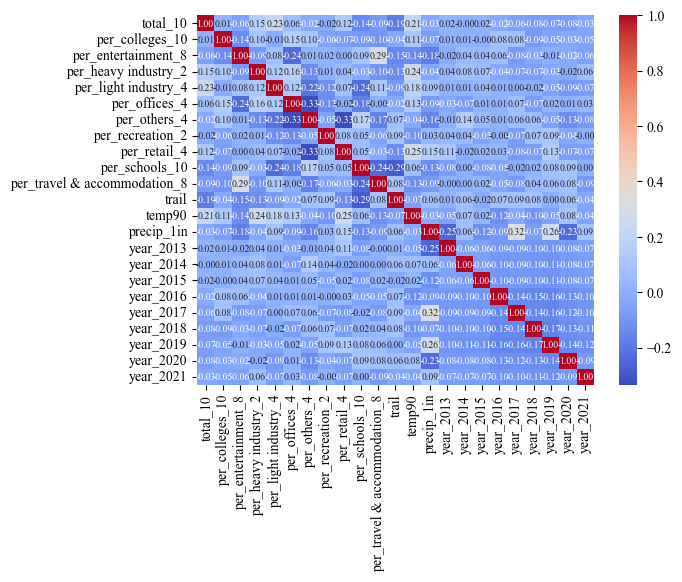

In [41]:
sns.heatmap(X_train[var].corr(), cmap = 'coolwarm', annot = True, fmt = '.2f', annot_kws = {'fontsize': 7})

In [42]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data['feature'] = var
vif_data['VIF'] = [variance_inflation_factor(X_train[var].values, i) for i in range(len(var))]
print(vif_data)

                         feature       VIF
0                       total_10  1.464490
1                per_colleges_10  1.253632
2            per_entertainment_8  3.836874
3           per_heavy industry_2  1.344753
4           per_light industry_4  1.726031
5                  per_offices_4  4.202029
6                   per_others_4  3.842854
7               per_recreation_2  1.149802
8                   per_retail_4  2.868808
9                 per_schools_10  2.473111
10  per_travel & accommodation_8  1.986850
11                         trail  4.985315
12                        temp90  2.174003
13                    precip_1in  3.697479
14                     year_2013  1.529906
15                     year_2014  1.654443
16                     year_2015  1.512860
17                     year_2016  2.216204
18                     year_2017  2.453318
19                     year_2018  2.235495
20                     year_2019  2.761993
21                     year_2020  1.822417
22         

In [43]:
# Scale data before estimation
scaler = StandardScaler()
scale_columns = var #['total_10', 'temp90']
X_train_scaled = X_train.copy()
X_train_scaled[scale_columns] = scaler.fit_transform(X_train[scale_columns])
X_test_scaled = X_test.copy()
X_test_scaled[scale_columns] = scaler.transform(X_test[scale_columns])

In [44]:
mnl = SMWrapperMNL
space = {'alpha': hp.uniform('alpha', 0, 1)}
best = optimize(mnl, space, n_iter = 100, random_state = random_state, cv = kf, X = X_train_scaled[var], Y = y_train)

Optimization terminated successfully    (Exit mode 0)                                                                  
            Current function value:                                                                                    
0.6652826907340506                                                                                                     
            Iterations:                                                                                                
171                                                                                                                    
            Function evaluations:                                                                                      
171                                                                                                                    
            Gradient evaluations:                                                                                      
171                                     

            Current function value:                                                                                    
0.7058006552381448                                                                                                     
            Iterations:                                                                                                
118                                                                                                                    
            Function evaluations:                                                                                      
118                                                                                                                    
            Gradient evaluations:                                                                                      
118                                                                                                                    
Optimization terminated successfully    

0.6647020931872858                                                                                                     
            Iterations:                                                                                                
172                                                                                                                    
            Function evaluations:                                                                                      
173                                                                                                                    
            Gradient evaluations:                                                                                      
172                                                                                                                    
Optimization terminated successfully    (Exit mode 0)                                                                  
            Current function value:     

            Iterations:                                                                                                
123                                                                                                                    
            Function evaluations:                                                                                      
124                                                                                                                    
            Gradient evaluations:                                                                                      
123                                                                                                                    
Optimization terminated successfully    (Exit mode 0)                                                                  
            Current function value:                                                                                    
0.7235383858764164                      

479                                                                                                                    
            Function evaluations:                                                                                      
479                                                                                                                    
            Gradient evaluations:                                                                                      
479                                                                                                                    
Optimization terminated successfully    (Exit mode 0)                                                                  
            Current function value:                                                                                    
0.595758822716056                                                                                                      
            Iterations:                 

...

C:\Users\Qianhua\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\base\l1_solvers_common.py:74: ConvergenceWarning: QC check did not pass for 64 out of 72 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)

C:\Users\Qianhua\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



Iteration limit reached    (Exit mode 9)                                                                               
            Current function value:                                                                                    
0.5384125004185969                                                                                                     
            Iterations:                                                                                                
500                                                                                                                    
            Function evaluations:                                                                                      
500                                                                                                                    
            Gradient evaluations:                                                                                      
500                                     

C:\Users\Qianhua\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\base\l1_solvers_common.py:74: ConvergenceWarning: QC check did not pass for 36 out of 72 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)

C:\Users\Qianhua\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



Iteration limit reached    (Exit mode 9)                                                                               
            Current function value:                                                                                    
0.5283245246490135                                                                                                     
            Iterations:                                                                                                
500                                                                                                                    
            Function evaluations:                                                                                      
504                                                                                                                    
            Gradient evaluations:                                                                                      
500                                     

C:\Users\Qianhua\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\base\l1_solvers_common.py:74: ConvergenceWarning: QC check did not pass for 28 out of 72 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)

C:\Users\Qianhua\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



In [45]:
print(best)

{'alpha': 0.025332358896977332}


In [47]:
best_params = best
mnl = SMWrapperMNL
ac_tr_mnl, ac_cv_mnl, ac_tt_mnl = model_performance(X_train = X_train[var], y_train = y_train, X_test = X_test[var], y_test = y_test, 
                                                    model = mnl, cv = kf, params = best_params, random_state = random_state)

C:\Users\Qianhua\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\discrete\discrete_model.py:3029: RuntimeWarning: overflow encountered in exp
  eXB = np.column_stack((np.ones(len(X)), np.exp(X)))
C:\Users\Qianhua\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\discrete\discrete_model.py:3030: RuntimeWarning: invalid value encountered in divide
  return eXB/eXB.sum(1)[:,None]
C:\Users\Qianhua\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\discrete\discrete_model.py:3061: RuntimeWarning: divide by zero encountered in log
  logprob = np.log(self.cdf(np.dot(self.exog,params)))
C:\Users\Qianhua\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\discrete\discrete_model.py:3062: RuntimeWarning: invalid value encountered in multiply
  return np.sum(d * logprob)


Iteration limit reached    (Exit mode 9)
            Current function value: 0.6178446302091284
            Iterations: 500
            Function evaluations: 520
            Gradient evaluations: 500
The prediction accuracy of train set is 53.4%
The confusion matrix is:
[[  6  32   0   0]
 [ 44 118   0   3]
 [  5  16   0   0]
 [  0   8   0   0]]
-----------------------------------------


C:\Users\Qianhua\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\base\l1_solvers_common.py:74: ConvergenceWarning: QC check did not pass for 32 out of 72 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
C:\Users\Qianhua\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\GSR\PSIP4\utilClassification.py:238: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if self.fit_intercept:
C:\Users\Qianhua\AppData\Local\Programs\Python\Python39\lib\site-pac

Iteration limit reached    (Exit mode 9)
            Current function value: 0.5939501638365656
            Iterations: 500
            Function evaluations: 521
            Gradient evaluations: 500


C:\Users\Qianhua\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\base\l1_solvers_common.py:74: ConvergenceWarning: QC check did not pass for 34 out of 72 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
C:\Users\Qianhua\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Qianhua\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\discrete\discrete_model.py:3029: RuntimeWarning: overflow encountered in exp
  eXB = np.column_stack((np.ones(len(X)), np.exp(X)))
C:\Users\Qianhua\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\discrete\discrete_model.py:3030: RuntimeWarning: invalid value encountered in divide
  return eXB/eXB.sum(1)[:,None]
C

...

C:\Users\Qianhua\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\base\l1_solvers_common.py:74: ConvergenceWarning: QC check did not pass for 36 out of 72 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
C:\Users\Qianhua\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Qianhua\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\discrete\discrete_model.py:3029: RuntimeWarning: overflow encountered in exp
  eXB = np.column_stack((np.ones(len(X)), np.exp(X)))
C:\Users\Qianhua\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\discrete\discrete_model.py:3030: RuntimeWarning: invalid value encountered in divide
  return eXB/eXB.sum(1)[:,None]
C

Iteration limit reached    (Exit mode 9)
            Current function value: 0.6140993888778777
            Iterations: 500
            Function evaluations: 520
            Gradient evaluations: 500


C:\Users\Qianhua\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\base\l1_solvers_common.py:74: ConvergenceWarning: QC check did not pass for 35 out of 72 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
C:\Users\Qianhua\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Qianhua\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\discrete\discrete_model.py:3029: RuntimeWarning: overflow encountered in exp
  eXB = np.column_stack((np.ones(len(X)), np.exp(X)))
C:\Users\Qianhua\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\discrete\discrete_model.py:3030: RuntimeWarning: invalid value encountered in divide
  return eXB/eXB.sum(1)[:,None]
C

Iteration limit reached    (Exit mode 9)
            Current function value: 0.5911870471942148
            Iterations: 500
            Function evaluations: 521
            Gradient evaluations: 500
The prediction accuracy of 10 fold cross-validation is 35.8%
-----------------------------------------
The prediction accuracy of test set is 53.4%
The confusion matrix is:
[[ 0  8  0  0]
 [11 31  0  0]
 [ 3  4  0  0]
 [ 0  1  0  0]]


C:\Users\Qianhua\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\base\l1_solvers_common.py:74: ConvergenceWarning: QC check did not pass for 28 out of 72 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
C:\Users\Qianhua\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\GSR\PSIP4\utilClassification.py:238: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if self.fit_intercept:
C:\Users\Qianhua\AppData\Local\Programs\Python\Python39\lib\site-pac

In [48]:
mnl = SMWrapperMNL(random_state = random_state, **best_params)
mnl = mnl.fit(X_train[var], y_train)
print(mnl.summary())

C:\Users\Qianhua\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\discrete\discrete_model.py:3029: RuntimeWarning: overflow encountered in exp
  eXB = np.column_stack((np.ones(len(X)), np.exp(X)))
C:\Users\Qianhua\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\discrete\discrete_model.py:3030: RuntimeWarning: invalid value encountered in divide
  return eXB/eXB.sum(1)[:,None]
C:\Users\Qianhua\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\discrete\discrete_model.py:3061: RuntimeWarning: divide by zero encountered in log
  logprob = np.log(self.cdf(np.dot(self.exog,params)))
C:\Users\Qianhua\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\discrete\discrete_model.py:3062: RuntimeWarning: invalid value encountered in multiply
  return np.sum(d * logprob)


Iteration limit reached    (Exit mode 9)
            Current function value: 0.6178446302091284
            Iterations: 500
            Function evaluations: 520
            Gradient evaluations: 500
                          MNLogit Regression Results                          
Dep. Variable:                  label   No. Observations:                  232
Model:                        MNLogit   Df Residuals:                      162
Method:                           MLE   Df Model:                           67
Date:                Thu, 23 Jan 2025   Pseudo R-squ.:                  0.3183
Time:                        17:09:37   Log-Likelihood:                -137.95
converged:                      False   LL-Null:                       -202.36
Covariance Type:            nonrobust   LLR p-value:                 8.560e-06
                     label=1       coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------

C:\Users\Qianhua\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\base\l1_solvers_common.py:74: ConvergenceWarning: QC check did not pass for 32 out of 72 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
C:\Users\Qianhua\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### Model performance

In [50]:
# compare between models
pd.options.display.float_format = '{:.2f}'.format
print(pd.DataFrame({'ac_train': [ac_tr_rfc, ac_tr_xgb, ac_tr_mnl],
                    'ac_cv': [ac_cv_rfc, ac_cv_xgb, ac_cv_mnl],
                    'ac_test': [ac_tt_rfc, ac_tt_xgb, ac_tt_mnl]}).T.rename(columns = {0: 'RFC',
                                                                                       1: 'XGB',
                                                                                       2: 'MNL'}).map('{:.1%}'.format))

            RFC    XGB    MNL
ac_train  97.4%  90.9%  53.4%
ac_cv     47.5%  51.7%  35.8%
ac_test   65.5%  72.4%  53.4%


### Prediction & Expansion

In [17]:
miovision_monthly_count = pd.read_csv('data/miovision_monthly_total_traffic.csv')
miovision_monthly_count.head()

,id,year,month,monthly_total_traffic
0,100_short,2013,3,12020.099828
1,101_short,2019,4,818.956292
2,101_short,2019,5,2121.327147
3,102_short,2015,2,387.341549
4,103_short,2014,7,3287.467337


In [18]:
print('There are {} unique shorterm locations with {} estimates of monthly total traffic.'.format(miovision_monthly_count.id.nunique(), len(miovision_monthly_count)))

There are 458 unique shorterm locations with 495 estimates of monthly total traffic.


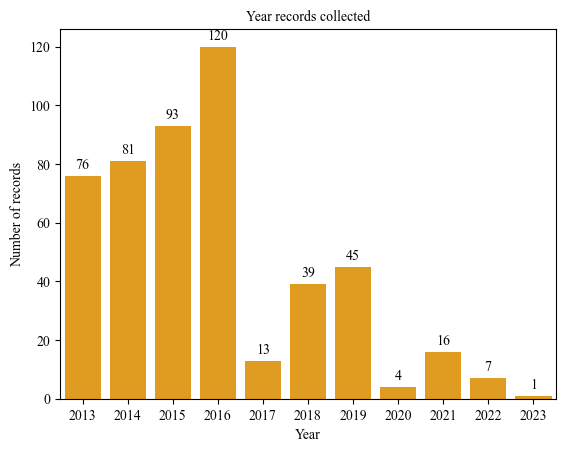

In [19]:
ax = sns.barplot(miovision_monthly_count.year.value_counts().sort_index(), color = 'orange')
ax.set_ylabel('Number of records')
ax.set_xlabel('Year')
ax.set_title('Year records collected')

for bar in ax.patches:
    ax.annotate(format(bar.get_height(), '.0f'),
               (bar.get_x() + bar.get_width()/2, bar.get_height()),
               ha = 'center', va = 'center',
               size = 10, xytext = (0, 8),
               textcoords = 'offset points')
    
plt.show()

In [20]:
# most locations have only one year records
miovision_monthly_count.groupby(['id'])['year'].nunique().sort_values(ascending = False).value_counts()

year
1    436
2     21
3      1
Name: count, dtype: int64

In [21]:
# most of the locations only have records from one month in a year
miovision_monthly_count.groupby(['id', 'year'])['month'].nunique().sort_values(ascending = False).value_counts()

month
1    467
2     14
Name: count, dtype: int64

### Prediction

In [22]:
# site_id - year pairs
site_year_df = miovision_monthly_count.groupby(['id', 'year']).nunique().reset_index().rename(columns = {'id': 'site_id'})
# prepare data for prediction
shorterm_data_encoded = data_preparation(site_year_df[['site_id', 'year']], landuse_information, explanatory_var_p1)

D:\GSR\PSIP4\utilClassification.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sites_df['trail'] = 0


In [23]:
shorterm_data_encoded.shape

(481, 134)

In [24]:
shorterm_data_encoded.head()

,trail,colleges_2,entertainment_2,heavy industry_2,light industry_2,offices_2,others_2,recreation_2,retail_2,schools_2,...,year_2014,year_2015,year_2016,year_2017,year_2018,year_2019,year_2020,year_2021,year_2022,year_2023
0,0,0.0,5.0,2.0,2.0,24.0,16.0,0.0,15.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0.0,0.0,0.0,0.0,2.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,0.0,11.0,0.0,0.0,12.0,9.0,0.0,9.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0.0,0.0,0.0,0.0,2.0,1.0,0.0,4.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


$$ weighted\_ef = \sum_{k=1}^{K}prob_k * ef_k $$

In [25]:
# drop the 2023 indicator column. No 2023 data in the longterm counters
shorterm_data_encoded = shorterm_data_encoded.drop('year_2023', axis = 1)

In [28]:
# predict month-to-year cluster membership for each short-term location in different year
prob = xgb.predict_proba(X = shorterm_data_encoded)

In [29]:
# calculate the weighted month-to-year expansion factor
month_to_year_group_expansion_factor = pd.read_csv('data/month_to_year_group_expansion_factor.csv')
weighted_ef = pd.DataFrame(np.dot(prob, np.array(month_to_year_group_expansion_factor).T))

In [30]:
# reset index of weighted expansion factor dataframe
weighted_ef[['site_id', 'year']] = site_year_df[['site_id', 'year']]
weighted_ef.set_index(['site_id', 'year'], inplace = True)

### Expansion

In [31]:
# get the weighted expansion factor for each month
miovision_monthly_count.loc[:, 'weighted_ef'] = miovision_monthly_count.apply(lambda x: weighted_ef.loc[(x.id, x.year), x.month-1], axis = 1)
# expand monthly count to annnual count
annual_count = miovision_monthly_count.groupby(['id', 'year'])[['monthly_total_traffic', 'weighted_ef']].sum().reset_index()
annual_count['annual_total_traffic'] = annual_count['monthly_total_traffic']/annual_count['weighted_ef']

In [32]:
annual_count.drop(['monthly_total_traffic', 'weighted_ef'], axis = 1, inplace = True)

In [33]:
annual_count.annual_total_traffic.describe()

count    4.810000e+02
mean     8.130989e+04
std      1.582526e+05
min      0.000000e+00
25%      8.073526e+03
50%      3.405164e+04
75%      9.087310e+04
max      1.709998e+06
Name: annual_total_traffic, dtype: float64

In [34]:
annual_count.groupby('year')['annual_total_traffic'].mean()

year
2013    159179.112194
2014     90719.160308
2015     52760.617015
2016     86697.818281
2017     63694.535508
2018     46821.890540
2019     49038.936070
2020      3317.954822
2021     21249.658689
2022     30881.862765
2023     47815.066498
Name: annual_total_traffic, dtype: float64

In [35]:
len(annual_count)

481

In [36]:
annual_count.id.nunique()

458

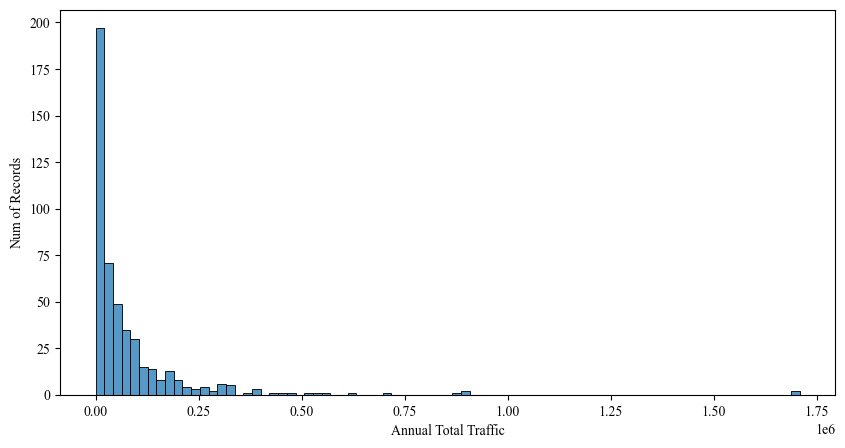

In [37]:
# Visualize the distribution of annual total traffic
plt.figure(figsize = (10, 5))

ax = sns.histplot(annual_count.annual_total_traffic)
ax.set_xlabel('Annual Total Traffic')
ax.set_ylabel('Num of Records')

plt.show()

### Prepare dataset for exposure modeling

In [38]:
explanatory_var_p1 = pd.read_excel('data/all_Locations_p1_11_26_2024.xlsx')
explanatory_var_p25 = pd.read_excel('data/all_Locations_p25_11_26_2024.xlsx')
explanatory_var_p5 = pd.read_excel('data/all_Locations_p5_11_26_2024.xlsx')

In [39]:
explanatory_var_p5 = explanatory_var_p5.rename(dict(zip(['2013','2014','2015','2016','2017','2018','2019','2020','2021','2022','2023','Avg Annual'],
                                   ['precip_5in_2013','precip_5in_2014','precip_5in_2015','precip_5in_2016','precip_5in_2017','precip_5in_2018','precip_5in_2019','precip_5in_2020','precip_5in_2021','precip_5in_2022','precip_5in_2023','precip_5in_avg_a'])))

In [40]:
no_use_col = ['Shape_Length', 'Shape_Area',  'totmeanstowork',
             'tottenure',
             'toteducattain', 'BUFF_DIST', 'zone_name', 'BZone_num',
             'permanent',
             'adj_x',
             'adj_y',
             'NEAR_WID',
             'NEAR_WATER',
             'NEAR_FC',
             'tasas_id', 'site_id', 'permanent', 'OBJECTID']

In [41]:
buffer_var = ['pct_white',
             'pct_transit',
             'pct_walk',
             'pct_bachelor_higher',
             'pct_no_veh',
             'totpop',
             'tothshld',
             'white',
             'totwalktowork',
             'tottransittowork',
             'num25over',
             'bachelor_higher',
             'tot_no_veh',
             'tot_length_Sum',
             'num_streets',
             'weighted_avg_D4A',
             'weighted_avg_D4B025',
             'weighted_avg_D4B050',
             'weighted_avg_D4C',
             'weighted_avg_D4D',
             'weighted_avg_D4E',
             'weighted_avg_D5BR',
             'weighted_avg_D5BE',
             'bus_emp_count',
             'business_sqft',
             'parks_sqft',
             'num_colleges',
             'num_schools']

In [42]:
intersection_var = ['NEAR_WATER', 
                    'slope',
                     'tasas_control_type',
                     'tasas_design_type',
                     'principal',
                     'minor',
                     'collector',
                     'speed_limit']

In [43]:
climate_var = explanatory_var_p1.columns[explanatory_var_p1.columns.str.contains('^t_|^snow_|^precip_')].to_list()

In [44]:
# deal with buffer variables
df = explanatory_var_p1[['latitude', 'longitude', 'location', 'id'] + buffer_var].merge(explanatory_var_p25[['id'] + buffer_var], on = 'id', suffixes=('_p1', '_p25'))
buffer_var_p5 = explanatory_var_p5[buffer_var].add_suffix('_p5')
buffer_var_p5['id'] = explanatory_var_p5['id']
df = df.merge(buffer_var_p5, on = 'id')

In [45]:
# deal with intersection var & climate var
df = df.merge(explanatory_var_p1[['id'] + intersection_var + climate_var], on = 'id')

In [46]:
df = annual_count.merge(df, on = 'id')

In [47]:
df['temp90'] = df.apply(lambda x: x['t_'+str(int(max(x.year, 2013)))], axis = 1)
df['snow'] = df.apply(lambda x: x['snow_'+str(int(max(x.year, 2013)))], axis = 1)
df['precip_5in'] = df.apply(lambda x: x['precip_p5in_'+str(int(max(x.year, 2013)))], axis = 1)
df['precip_1in'] = df.apply(lambda x: x['precip_1in_'+str(int(max(x.year, 2013)))], axis = 1)

In [48]:
df = df.drop(climate_var, axis = 1)

In [49]:
df.columns.to_list()

['id',
 'year',
 'annual_total_traffic',
 'latitude',
 'longitude',
 'location',
 'pct_white_p1',
 'pct_transit_p1',
 'pct_walk_p1',
 'pct_bachelor_higher_p1',
 'pct_no_veh_p1',
 'totpop_p1',
 'tothshld_p1',
 'white_p1',
 'totwalktowork_p1',
 'tottransittowork_p1',
 'num25over_p1',
 'bachelor_higher_p1',
 'tot_no_veh_p1',
 'tot_length_Sum_p1',
 'num_streets_p1',
 'weighted_avg_D4A_p1',
 'weighted_avg_D4B025_p1',
 'weighted_avg_D4B050_p1',
 'weighted_avg_D4C_p1',
 'weighted_avg_D4D_p1',
 'weighted_avg_D4E_p1',
 'weighted_avg_D5BR_p1',
 'weighted_avg_D5BE_p1',
 'bus_emp_count_p1',
 'business_sqft_p1',
 'parks_sqft_p1',
 'num_colleges_p1',
 'num_schools_p1',
 'pct_white_p25',
 'pct_transit_p25',
 'pct_walk_p25',
 'pct_bachelor_higher_p25',
 'pct_no_veh_p25',
 'totpop_p25',
 'tothshld_p25',
 'white_p25',
 'totwalktowork_p25',
 'tottransittowork_p25',
 'num25over_p25',
 'bachelor_higher_p25',
 'tot_no_veh_p25',
 'tot_length_Sum_p25',
 'num_streets_p25',
 'weighted_avg_D4A_p25',
 'weighted_a

In [50]:
df.to_csv('data/exposure_modeling_variables_012825.csv', index = False)

In [51]:
import plotly.express as px

df['site_year'] = df.apply(lambda x: x.location + ', ' + str(x.year), axis = 1)
fig = px.scatter_mapbox(df,
                        lat = 'latitude', lon = 'longitude',
                        hover_name = 'site_year',
                        size = 'annual_total_traffic',
                        zoom = 8, height = 800, width = 1600)
fig.update_layout(mapbox_style = 'open-street-map')
fig.show()